BRUCE CHENGDOU WEI

Lloyds Banking Group Project

In [1]:
# 1 Project Background
# 2 Data Cleaning
# 3 Feature Engineering
# 4 Exploratory Analysis
# 5 Model Development
# 6 Model Insights


In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/loans_dataset.xlsx")

df = pd.read_excel(data_path)

print(df.shape)
df.head()

(18324, 31)


,id,addr_state,annual_inc,emp_length,emp_title,home_ownership,installment,loan_amnt,purpose,term,...,num_il_tl,num_op_rev_tl,num_tl_90g_dpd_24m,num_tl_op_past_12m,open_acc,percent_bc_gt_75,pub_rec_bankruptcies,total_acc,total_bal_ex_mort,loan_status
0,802173,CA,72000.0,3 years,CA. Dept. Of Corrections,MORTGAGE,395.66,12000,debt_consolidation,36 months,...,NaN,NaN,NaN,NaN,16,NaN,0,23,NaN,Fully Paid
1,14518910,TX,97500.0,1 year,Curriculum & Implementation Manager,RENT,966.47,35000,debt_consolidation,60 months,...,2.0,12.0,0.0,1.0,13,87.5,0,24,84227.0,Fully Paid
2,54333324,NY,120000.0,1 year,Senior manager,RENT,806.57,25000,credit_card,36 months,...,2.0,7.0,0.0,1.0,8,100.0,0,16,39124.0,Fully Paid
3,62247022,CA,130000.0,10+ years,Border Patrol Agent,RENT,846.17,25225,debt_consolidation,36 months,...,9.0,3.0,0.0,2.0,8,50.0,0,24,123331.0,Fully Paid
4,71986114,TX,58296.0,10+ years,Account Manager,MORTGAGE,41.79,1200,other,36 months,...,7.0,6.0,0.0,0.0,9,100.0,0,17,51794.0,Fully Paid


In [3]:
# 1 Project Background

In [4]:
# check loan status
df["loan_status"].value_counts()

loan_status
Fully Paid     14418
Charged Off     3906
Name: count, dtype: int64

In [5]:
# percentage 
df["loan_status"].value_counts(normalize=True)

loan_status
Fully Paid     0.786837
Charged Off    0.213163
Name: proportion, dtype: float64

In [6]:
# type
df.dtypes

id                          int64
addr_state                 object
annual_inc                float64
emp_length                 object
emp_title                  object
home_ownership             object
installment               float64
loan_amnt                   int64
purpose                    object
term                       object
int_rate                  float64
avg_cur_bal               float64
inq_last_12m              float64
max_bal_bc                float64
mo_sin_old_il_acct        float64
mo_sin_old_rev_tl_op      float64
mo_sin_rcnt_rev_tl_op     float64
mo_sin_rcnt_tl            float64
mort_acc                  float64
mths_since_last_delinq    float64
num_bc_tl                 float64
num_il_tl                 float64
num_op_rev_tl             float64
num_tl_90g_dpd_24m        float64
num_tl_op_past_12m        float64
open_acc                    int64
percent_bc_gt_75          float64
pub_rec_bankruptcies        int64
total_acc                   int64
total_bal_ex_m

In [7]:
# what is lost 1
df.isna().sum().sort_values(ascending=False)

mths_since_last_delinq    9048
inq_last_12m              8929
max_bal_bc                8929
emp_title                 1282
emp_length                1174
mo_sin_old_il_acct        1132
percent_bc_gt_75           610
avg_cur_bal                566
num_op_rev_tl              564
mo_sin_rcnt_rev_tl_op      564
num_il_tl                  564
mo_sin_old_rev_tl_op       564
mo_sin_rcnt_tl             564
num_bc_tl                  564
num_tl_op_past_12m         564
num_tl_90g_dpd_24m         564
mort_acc                   398
total_bal_ex_mort          398
loan_amnt                    0
annual_inc                   0
addr_state                   0
home_ownership               0
installment                  0
id                           0
purpose                      0
term                         0
int_rate                     0
open_acc                     0
pub_rec_bankruptcies         0
total_acc                    0
loan_status                  0
dtype: int64

In [8]:
# what is lost 2
(df.isna().mean()*100).sort_values(ascending=False)

mths_since_last_delinq    49.377865
inq_last_12m              48.728444
max_bal_bc                48.728444
emp_title                  6.996289
emp_length                 6.406898
mo_sin_old_il_acct         6.177690
percent_bc_gt_75           3.328967
avg_cur_bal                3.088845
num_op_rev_tl              3.077931
mo_sin_rcnt_rev_tl_op      3.077931
num_il_tl                  3.077931
mo_sin_old_rev_tl_op       3.077931
mo_sin_rcnt_tl             3.077931
num_bc_tl                  3.077931
num_tl_op_past_12m         3.077931
num_tl_90g_dpd_24m         3.077931
mort_acc                   2.172015
total_bal_ex_mort          2.172015
loan_amnt                  0.000000
annual_inc                 0.000000
addr_state                 0.000000
home_ownership             0.000000
installment                0.000000
id                         0.000000
purpose                    0.000000
term                       0.000000
int_rate                   0.000000
open_acc                   0

In [9]:
df["emp_length"].unique()

array(['3 years', '1 year', '10+ years', '< 1 year', '8 years', '5 years',
       '9 years', nan, '2 years', '6 years', '7 years', '4 years'],
      dtype=object)

In [10]:
# Data Cleaning

In [11]:
# transfer emp_length into float
df["emp_length"] = df["emp_length"].replace({
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
})

df["emp_length"] = df["emp_length"].astype(float)

df["emp_length"].unique()

/var/folders/r8/3qjthfds5hn2xjgnhhc3148w0000gn/T/ipykernel_37128/1805145605.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["emp_length"] = df["emp_length"].replace({


array([ 3.,  1., 10.,  0.,  8.,  5.,  9., nan,  2.,  6.,  7.,  4.])

In [12]:
# 3 Feature Engineering

In [13]:
# delete ID
df = df.drop(columns=["id"])

# transfer loan_status into int
df["loan_status"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
}).astype(int)

# transfer term into int
df["term"] = df["term"].str.replace(" months","").astype(int)

df.head()

,addr_state,annual_inc,emp_length,emp_title,home_ownership,installment,loan_amnt,purpose,term,int_rate,...,num_il_tl,num_op_rev_tl,num_tl_90g_dpd_24m,num_tl_op_past_12m,open_acc,percent_bc_gt_75,pub_rec_bankruptcies,total_acc,total_bal_ex_mort,loan_status
0,CA,72000.0,3.0,CA. Dept. Of Corrections,MORTGAGE,395.66,12000,debt_consolidation,36,0.1149,...,NaN,NaN,NaN,NaN,16,NaN,0,23,NaN,0
1,TX,97500.0,1.0,Curriculum & Implementation Manager,RENT,966.47,35000,debt_consolidation,60,0.2199,...,2.0,12.0,0.0,1.0,13,87.5,0,24,84227.0,0
2,NY,120000.0,1.0,Senior manager,RENT,806.57,25000,credit_card,36,0.0999,...,2.0,7.0,0.0,1.0,8,100.0,0,16,39124.0,0
3,CA,130000.0,10.0,Border Patrol Agent,RENT,846.17,25225,debt_consolidation,36,0.1269,...,9.0,3.0,0.0,2.0,8,50.0,0,24,123331.0,0
4,TX,58296.0,10.0,Account Manager,MORTGAGE,41.79,1200,other,36,0.1531,...,7.0,6.0,0.0,0.0,9,100.0,0,17,51794.0,0


In [14]:
# check types of the values
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].nunique())

addr_state 51
emp_title 10040
home_ownership 5
purpose 14


In [15]:
# emp_title is a mess
df = df.drop(columns=["emp_title"])
df.shape

(18324, 29)

In [16]:
# for the missing values

import numpy as np

# find all the num
numeric_cols = df.select_dtypes(include=[np.number]).columns

# median imputation
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# check
df.isna().sum().sort_values(ascending=False)

addr_state                0
annual_inc                0
emp_length                0
home_ownership            0
installment               0
loan_amnt                 0
purpose                   0
term                      0
int_rate                  0
avg_cur_bal               0
inq_last_12m              0
max_bal_bc                0
mo_sin_old_il_acct        0
mo_sin_old_rev_tl_op      0
mo_sin_rcnt_rev_tl_op     0
mo_sin_rcnt_tl            0
mort_acc                  0
mths_since_last_delinq    0
num_bc_tl                 0
num_il_tl                 0
num_op_rev_tl             0
num_tl_90g_dpd_24m        0
num_tl_op_past_12m        0
open_acc                  0
percent_bc_gt_75          0
pub_rec_bankruptcies      0
total_acc                 0
total_bal_ex_mort         0
loan_status               0
dtype: int64

In [17]:
# get_dummies() for One-Hot Encoding
# drop_first=True for avoiding dummy variable trap

categorical_cols = ["addr_state", "home_ownership", "purpose"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# check
df.shape

df.head()

,annual_inc,emp_length,installment,loan_amnt,term,int_rate,avg_cur_bal,inq_last_12m,max_bal_bc,mo_sin_old_il_acct,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,72000.0,3.0,395.66,12000,36,0.1149,7137.0,2.0,4244.0,129.0,...,False,False,False,False,False,False,False,False,False,False
1,97500.0,1.0,966.47,35000,60,0.2199,7019.0,2.0,4244.0,148.0,...,False,False,False,False,False,False,False,False,False,False
2,120000.0,1.0,806.57,25000,36,0.0999,4891.0,2.0,4244.0,128.0,...,False,False,False,False,False,False,False,False,False,False
3,130000.0,10.0,846.17,25225,36,0.1269,17619.0,2.0,4244.0,130.0,...,False,False,False,False,False,False,False,False,False,False
4,58296.0,10.0,41.79,1200,36,0.1531,12321.0,1.0,10372.0,167.0,...,False,False,False,False,False,True,False,False,False,False


In [18]:
# save figure
from pathlib import Path

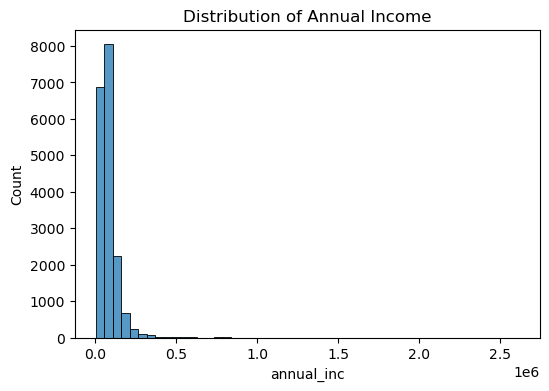

In [19]:
# check distribution shape
# could be fun

import matplotlib.pyplot as plt
import seaborn as sns

# Annual income
plt.figure(figsize=(6,4))
sns.histplot(df["annual_inc"], bins=50)
plt.title("Distribution of Annual Income")

plt.savefig(Path("../outputs/annual_income_distribution.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()


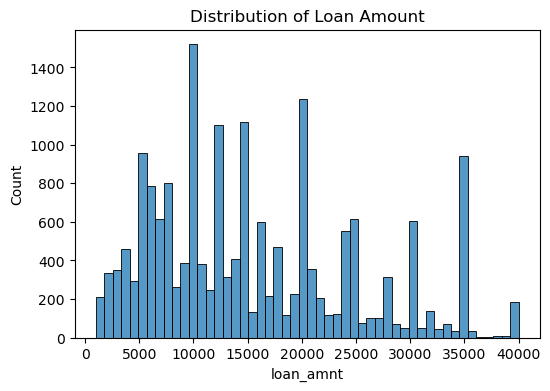

In [20]:
# check distribution shape 2
# loan amount

plt.figure(figsize=(6,4))
sns.histplot(df["loan_amnt"], bins=50)
plt.title("Distribution of Loan Amount")

plt.savefig(Path("../outputs/Loan_Amount_distribution.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()


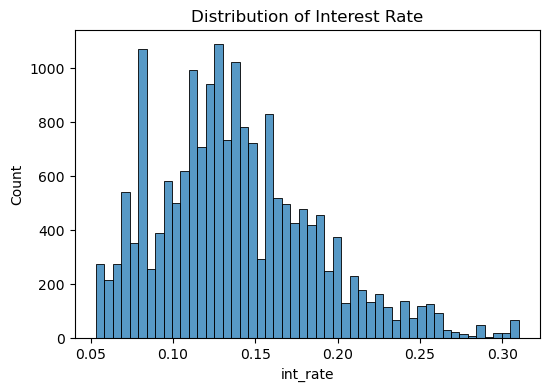

In [21]:
# check distribution shape 3
# interest rate

plt.figure(figsize=(6,4))
sns.histplot(df["int_rate"], bins=50)
plt.title("Distribution of Interest Rate")

plt.savefig(Path("../outputs/Interest_Rate_distribution.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

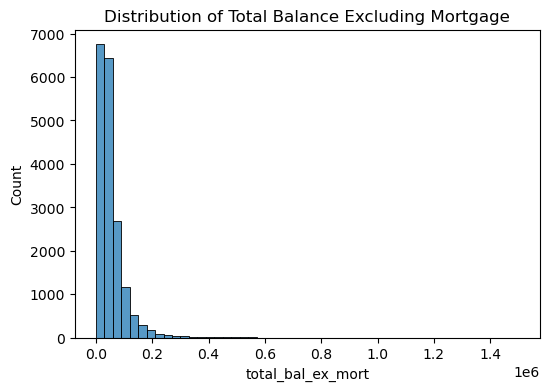

In [22]:
# check distribution shape 4
# Total Balance Excluding Mortgage

plt.figure(figsize=(6,4))
sns.histplot(df["total_bal_ex_mort"], bins=50)
plt.title("Distribution of Total Balance Excluding Mortgage")

plt.savefig(Path("../outputs/Total_Balance_Excluding_Mortgage_distribution.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

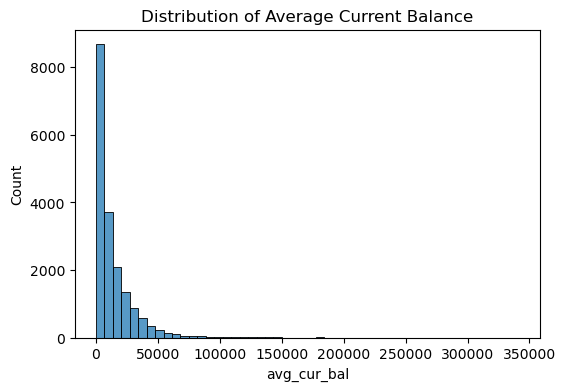

In [23]:
# check distribution shape 5
# Average Current Balance

plt.figure(figsize=(6,4))
sns.histplot(df["avg_cur_bal"], bins=50)
plt.title("Distribution of Average Current Balance")

plt.savefig(Path("../outputs/Average_Current_Balance_distribution.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

In [24]:
# 4 Exploratory Analysis

In [25]:
# Risk Segmentation

df.groupby("loan_status")[[
    "annual_inc",
    "loan_amnt",
    "int_rate",
    "installment",
    "avg_cur_bal",
    "total_bal_ex_mort",
    "inq_last_12m",
    "percent_bc_gt_75"
]].mean()

,annual_inc,loan_amnt,int_rate,installment,avg_cur_bal,total_bal_ex_mort,inq_last_12m,percent_bc_gt_75
loan_status,,,,,,,,
0,81997.863500,15262.562422,0.132291,461.300117,13993.842350,51609.043279,2.112151,44.860985
1,73451.586078,16482.750896,0.161450,490.587033,10603.227343,49771.682540,2.312084,47.638121


In [26]:
# 5 Model Development

In [27]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(14659, 92)
(3665, 92)


In [28]:
# Logistic Regression baseline

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [29]:
# accuracy
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7874488403819918

In [30]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      2884
           1       0.75      0.00      0.01       781

    accuracy                           0.79      3665
   macro avg       0.77      0.50      0.44      3665
weighted avg       0.78      0.79      0.69      3665



In [31]:
# the recall is 0, unacceptable 

In [32]:
# roc and auc
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.6312917220889325)

In [33]:
# adjust class weight

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.86      0.66      0.75      2884
           1       0.33      0.62      0.43       781

    accuracy                           0.65      3665
   macro avg       0.59      0.64      0.59      3665
weighted avg       0.75      0.65      0.68      3665

ROC-AUC: 0.6905883669181905


In [34]:
# Feature Importance

In [35]:
# Coefficients
import pandas as pd

coef = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coef = coef.sort_values(by="coefficient", ascending=False)

coef.head(15)

,feature,coefficient
78,home_ownership_RENT,0.552150
75,home_ownership_MORTGAGE,0.474256
5,int_rate,0.435269
77,home_ownership_OWN,0.314896
4,term,0.288302
2,installment,0.277258
81,purpose_educational,0.085304
16,num_il_tl,0.080915
17,num_op_rev_tl,0.065183
19,num_tl_op_past_12m,0.059660


In [36]:
coef.tail(15)

,feature,coefficient
0,annual_inc,-0.072752
36,addr_state_IA,-0.072770
32,addr_state_DE,-0.083209
64,addr_state_SC,-0.084045
38,addr_state_IL,-0.088864
34,addr_state_GA,-0.097682
58,addr_state_NY,-0.098524
29,addr_state_CO,-0.101278
13,mort_acc,-0.105979
6,avg_cur_bal,-0.109069


In [37]:
# threshold tuning
# it was P(default) > 0.5, we can lower this, so can catch more. we use 0.3 here.

y_prob = model.predict_proba(X_test_scaled)[:,1]

import numpy as np

y_pred_03 = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_03))


              precision    recall  f1-score   support

           0       0.94      0.21      0.35      2884
           1       0.25      0.95      0.39       781

    accuracy                           0.37      3665
   macro avg       0.59      0.58      0.37      3665
weighted avg       0.79      0.37      0.36      3665



In [38]:
# to avoid too many False Positives, keep the default threshold 0.5

In [39]:
# 6 Model Insights

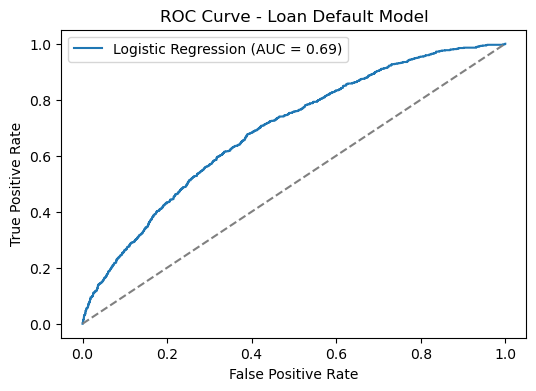

In [40]:
# ROC curve

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
# plt.plot(fpr, tpr, label="Logistic Regression (AUC = 0.69)")
auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
plt.plot([0,1],[0,1],'--', color="grey")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Default Model")
plt.legend()

plt.savefig(Path("../outputs/ROC_Curve.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

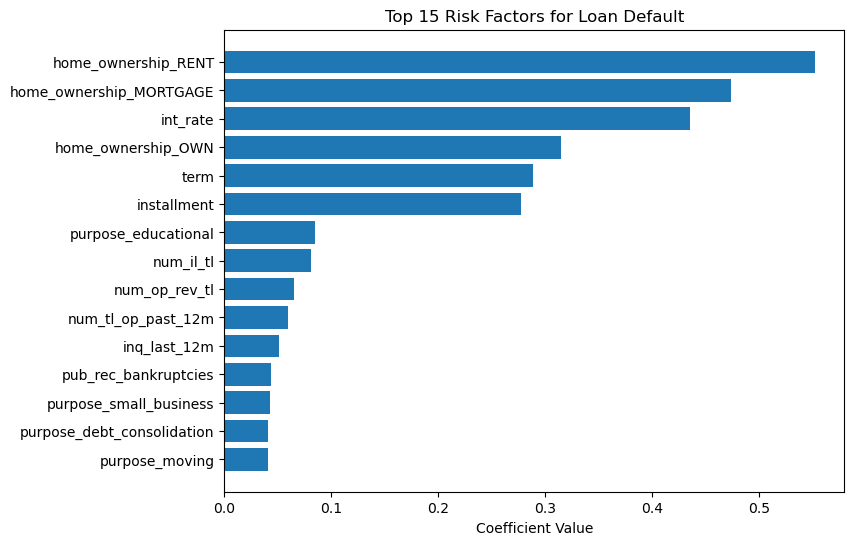

In [41]:
# Top 15 Risk Factors

coef = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coef = coef.sort_values(by="coefficient", ascending=False)

top_risk = coef.head(15)
top_risk

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(top_risk["feature"], top_risk["coefficient"])

plt.xlabel("Coefficient Value")
plt.title("Top 15 Risk Factors for Loan Default")

plt.gca().invert_yaxis()

plt.savefig(Path("../outputs/TOP15_Risk_Factors.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

In [42]:
# feature label mapping

feature_labels = {
    "int_rate": "Interest Rate",
    "term": "Loan Term",
    "installment": "Monthly Installment",
    "inq_last_12m": "Credit Inquiries (12m)",
    "num_tl_op_past_12m": "Accounts Opened (12m)",
    "num_op_rev_tl": "Open Revolving Accounts",
    "num_il_tl": "Installment Accounts",
    "pub_rec_bankruptcies": "Bankruptcy Records",
    "home_ownership_RENT": "Home Ownership: Rent",
    "home_ownership_MORTGAGE": "Home Ownership: Mortgage",
    "home_ownership_OWN": "Home Ownership: Own",
    "purpose_small_business": "Loan Purpose: Small Business",
    "purpose_debt_consolidation": "Loan Purpose: Debt Consolidation",
    "purpose_moving": "Loan Purpose: Moving",
    "purpose_educational": "Loan Purpose: Education"
}

# Apply label mapping

top_risk_plot = top_risk.copy()

top_risk_plot["label"] = top_risk_plot["feature"].map(feature_labels)

# the rest keep the same
top_risk_plot["label"] = top_risk_plot["label"].fillna(top_risk_plot["feature"])

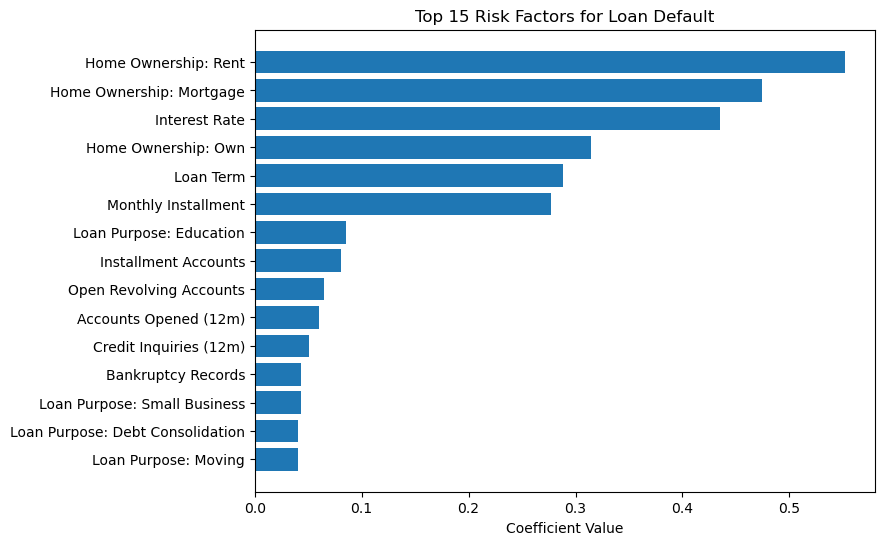

In [43]:
# re plot

plt.figure(figsize=(8,6))

plt.barh(top_risk_plot["label"], top_risk_plot["coefficient"])

plt.xlabel("Coefficient Value")
plt.title("Top 15 Risk Factors for Loan Default")

plt.gca().invert_yaxis()

plt.savefig(
    Path("../outputs/Key_Risk_Factors_of_Loan_Default.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()